J=0.8, mu=0.7, n_normal=1, p_normal=5.84777e-12, n_sc=1, Delta0=0
J=0.8, mu=0.678188, n_normal=1, p_normal=5.8975e-12, n_sc=1, Delta0=0
J=0.8, mu=0.656376, n_normal=1, p_normal=6.17462e-12, n_sc=1, Delta0=0
J=0.8, mu=0.634564, n_normal=1, p_normal=5.87619e-12, n_sc=1, Delta0=0
J=0.8, mu=0.612752, n_normal=1, p_normal=5.94724e-12, n_sc=1, Delta0=0
J=0.8, mu=0.59094, n_normal=1, p_normal=5.96856e-12, n_sc=1, Delta0=0
J=0.8, mu=0.569128, n_normal=1, p_normal=6.13198e-12, n_sc=1, Delta0=0
J=0.8, mu=0.547315, n_normal=1, p_normal=5.8904e-12, n_sc=1, Delta0=0
J=0.8, mu=0.525503, n_normal=1, p_normal=6.02363e-12, n_sc=1, Delta0=0
J=0.8, mu=0.503691, n_normal=1, p_normal=6.09468e-12, n_sc=1, Delta0=0
J=0.8, mu=0.481879, n_normal=1, p_normal=5.93836e-12, n_sc=1, Delta0=0
J=0.8, mu=0.460067, n_normal=1, p_normal=6.06448e-12, n_sc=1, Delta0=0
J=0.8, mu=0.438255, n_normal=1, p_normal=6.04761e-12, n_sc=1, Delta0=0
J=0.8, mu=0.416443, n_normal=1, p_normal=6.31983e-12, n_sc=1, Delta0=0
J=0.8, mu=0.39

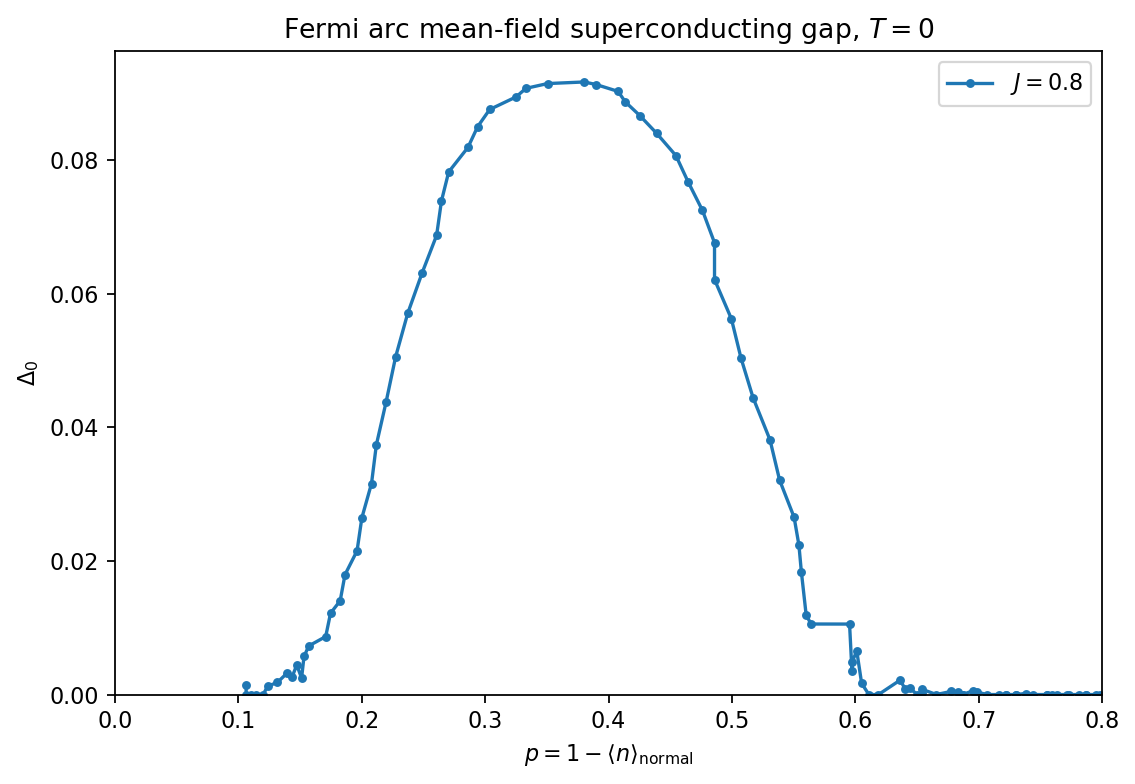

1001.9316208362579 seconds


In [ ]:
# This code computes the mean-field superconducting gap (interaction term is exact) for a Fermi arc model at zero temperature, as a function of normal-state doping. It uses a triangular k-point mesh and solves the self-consistent gap equation for various chemical potentials (mu) and exchange interaction strengths (J). The results are plotted and saved to a file.
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize


start_time = time.time()


def state_index(occ):
    return sum(int(n) << i for i, n in enumerate(occ))


def annihilation_operator(mode, n_modes=4):
    dim = 2**n_modes
    op = np.zeros((dim, dim), dtype=complex)

    for state in range(dim):
        if not ((state >> mode) & 1):
            continue

        new_state = state & ~(1 << mode)
        occupied_before = sum((state >> j) & 1 for j in range(mode))
        sign = (-1) ** occupied_before
        op[new_state, state] = sign

    return op


def band_no_mu(kx, ky, hop):
    cx = np.cos(kx)
    cy = np.cos(ky)
    t1, t2 = hop

    return (
        -2.0 * (cx + cy)
        - 4.0 * t1 * cx * cy
        - 4.0 * t2 * (cx * cx + cy * cy - 1.0)
    )


def band_energy(kx, ky, mu, hop):
    return band_no_mu(kx, ky, hop) - mu


def pair_form_factor(kx, ky):
    return np.cos(kx) - np.cos(ky)


def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu

    if T < 1e-8:
        T = 1e-8

    beta = 1.0 / T

    E_0 = np.zeros_like(epsilon_minus_mu)
    E_1 = -beta * epsilon_Q_minus_mu
    E_2 = -beta * (epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta * epsilon_minus_mu

    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])

    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = (
        np.exp(E_0 - E_max)
        + np.exp(E_1 - E_max)
        + np.exp(E_2 - E_max)
        + np.exp(E_3 - E_max)
    )

    return numerator / denominator


def average_occupation(mu, T, U, KX, KY, N, hop):
    epsilon = band_no_mu(KX, KY, hop)
    epsilon_Q = band_no_mu(KX + np.pi, KY + np.pi, hop)

    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)

    return 2.0 * np.sum(n_k) / N


def block_matrix_elements(kx, ky, mu, hop, U, Delta0):
    xi_k = band_energy(kx, ky, mu, hop)
    xi_kq = band_energy(kx + np.pi, ky + np.pi, mu, hop)

    delta_k = Delta0 * pair_form_factor(kx, ky)
    d = delta_k
    dc = np.conjugate(delta_k)

    h_sz_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_2 = [(1, 0, 0, 1)]

    h_sz_minus_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_minus_2 = [(0, 1, 1, 0)]

    h_sz_1_a = np.array(
        [
            [xi_k, dc],
            [d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_a = [(1, 0, 0, 0), (1, 1, 0, 1)]

    h_sz_1_d = np.array(
        [
            [xi_kq, dc],
            [d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_d = [(0, 0, 0, 1), (1, 0, 1, 1)]

    h_sz_minus_1_b = np.array(
        [
            [xi_kq, -dc],
            [-d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_b = [(0, 1, 0, 0), (1, 1, 1, 0)]

    h_sz_minus_1_c = np.array(
        [
            [xi_k, -dc],
            [-d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_c = [(0, 0, 1, 0), (0, 1, 1, 1)]

    h_sz_0_4 = np.array(
        [
            [0.0, dc, dc, 0.0],
            [d, 2.0 * xi_k, 0.0, -dc],
            [d, 0.0, 2.0 * xi_kq, -dc],
            [0.0, -d, -d, 2.0 * (xi_k + xi_kq + U)],
        ],
        dtype=complex,
    )
    basis_sz_0_4 = [
        (0, 0, 0, 0),
        (1, 0, 1, 0),
        (0, 1, 0, 1),
        (1, 1, 1, 1),
    ]

    h_interacting_pair = np.array([[xi_k + xi_kq + U]], dtype=complex)
    basis_ab = [(1, 1, 0, 0)]
    basis_cd = [(0, 0, 1, 1)]

    return [
        (h_sz_2, basis_sz_2),
        (h_sz_1_a, basis_sz_1_a),
        (h_sz_1_d, basis_sz_1_d),
        (h_sz_0_4, basis_sz_0_4),
        (h_interacting_pair, basis_ab),
        (h_interacting_pair, basis_cd),
        (h_sz_minus_1_b, basis_sz_minus_1_b),
        (h_sz_minus_1_c, basis_sz_minus_1_c),
        (h_sz_minus_2, basis_sz_minus_2),
    ]


def diagonalize_sector_block(kx, ky, mu, hop, U, Delta0):
    energies_all = []
    vectors_all = []

    for h_block, basis_occ in block_matrix_elements(kx, ky, mu, hop, U, Delta0):
        energies, vectors = np.linalg.eigh(h_block)
        basis_indices = [state_index(occ) for occ in basis_occ]

        for n in range(len(energies)):
            full_vector = np.zeros(16, dtype=complex)
            full_vector[basis_indices] = vectors[:, n]
            energies_all.append(energies[n])
            vectors_all.append(full_vector)

    order = np.argsort(np.real(energies_all))
    energies_all = np.array(energies_all, dtype=float)[order]
    vectors_all = np.array(vectors_all, dtype=complex).T[:, order]

    return energies_all, vectors_all


def sector_operators():
    c_ops = [annihilation_operator(i) for i in range(4)]
    pair_op = c_ops[2] @ c_ops[0]

    return c_ops, pair_op


C_OPS, PAIR_OP = sector_operators()
CD_OPS = [op.conj().T for op in C_OPS]
N_OPS = [CD_OPS[i] @ C_OPS[i] for i in range(4)]
N_TOTAL_OP = sum(N_OPS)


def ground_state_expectation(kx, ky, mu, hop, U, Delta0, op):
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)

    ground = np.argmin(energies)
    ground_vec = vectors[:, ground]

    return ground_vec.conj() @ op @ ground_vec


def pair_expectation_for_k(kx, ky, mu, hop, U, Delta0):
    return ground_state_expectation(kx, ky, mu, hop, U, Delta0, PAIR_OP)


def sector_density(kx, ky, mu, hop, U, Delta0):
    n_expect = ground_state_expectation(kx, ky, mu, hop, U, Delta0, N_TOTAL_OP)

    return 0.5 * np.real(n_expect)


def triangular_kmesh(nk1d):
    points = []
    weights = []

    for ix in range(nk1d):
        for iy in range(ix + 1):
            kx = ix * np.pi / nk1d
            ky = iy * np.pi / nk1d

            points.append((kx, ky))
            weights.append(0.5 if ix == iy else 1.0)

    return np.array(points, dtype=float), np.array(weights, dtype=float)


def solve_gap_delta0(k_points, k_weights, J, mu, hop, U, bracket=(1e-8, 1.0)):
    def new_delta(delta0):
        vals = []

        for (kx, ky), weight in zip(k_points, k_weights):
            gk = pair_form_factor(kx, ky)
            pair_avg = pair_expectation_for_k(kx, ky, mu, hop, U, delta0)
            vals.append(weight * gk * pair_avg)

        return float(np.real(-J * np.sum(vals) / np.sum(k_weights)))

    def residual(delta0):
        return new_delta(delta0) - delta0

    lo, hi = bracket

    f_lo = residual(lo)
    f_hi = residual(hi)

    while f_lo * f_hi > 0.0 and hi < 20.0:
        hi *= 2.0
        f_hi = residual(hi)

    if f_lo * f_hi > 0.0:
        return 0.0

    sol = optimize.root_scalar(
        residual,
        bracket=(lo, hi),
        xtol=1e-10,
        rtol=1e-10,
    )

    return sol.root if sol.converged else 0.0


def filling_for_delta0(k_points, k_weights, mu, hop, U, Delta0):
    fillings = []

    for (kx, ky), weight in zip(k_points, k_weights):
        density_k = sector_density(kx, ky, mu, hop, U, Delta0)
        fillings.append(weight * density_k)

    return float(np.sum(fillings) / np.sum(k_weights))


def gap_and_filling_for_mu(k_points, k_weights, J, mu, hop, U):
    Delta0 = solve_gap_delta0(
        k_points,
        k_weights,
        J,
        mu,
        hop,
        U,
        bracket=(1e-8, max(abs(J), 1e-4)),
    )

    filling_sc = filling_for_delta0(k_points, k_weights, mu, hop, U, Delta0)

    return filling_sc, Delta0


# -------------------------- user parameters --------------------------
hop = np.array([-0.2, 0.1])
U = 2
J_values = [0.8]

nk_gap = 64
mu_values = np.linspace(0.70, -2.55, 150)

# Mesh for self-consistent zero-temperature gap.
k_points, k_weights = triangular_kmesh(nk_gap)

# Mesh for normal-state average_occupation.
Nk_density = 64
kx_list = np.linspace(-np.pi, np.pi, Nk_density, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk_density, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk_density * Nk_density

T_threshold = 1e-6

plt.figure(figsize=(7.2, 5.0), dpi=160)

for J in J_values:
    normal_dopings = []
    sc_fillings = []
    gaps = []

    curve_start = time.time()

    for mu in mu_values:
        filling_sc, Delta0 = gap_and_filling_for_mu(
            k_points,
            k_weights,
            J=J,
            mu=mu,
            hop=hop,
            U=U,
        )

        n_normal = average_occupation(
            mu=mu,
            T=T_threshold,
            U=U,
            KX=KX,
            KY=KY,
            N=N,
            hop=hop,
        )

        p_normal = 1.0 - n_normal

        sc_fillings.append(filling_sc)
        normal_dopings.append(p_normal)
        gaps.append(Delta0)

        print(
            f"J={J:.6g}, mu={mu:.6g}, "
            f"n_normal={n_normal:.6g}, p_normal={p_normal:.6g}, "
            f"n_sc={filling_sc:.6g}, Delta0={Delta0:.6g}"
        )

    normal_dopings = np.array(normal_dopings)
    sc_fillings = np.array(sc_fillings)
    gaps = np.array(gaps)

    # Same doping mask as the variational-method code.
    mask_lower = normal_dopings >= 0.1
    mask_upper = normal_dopings < 0.8
    mask_combined = mask_lower & mask_upper

    x_final = normal_dopings[mask_combined]
    gap_final = gaps[mask_combined]
    sc_filling_final = sc_fillings[mask_combined]

    sort_indices = np.argsort(x_final)

    x_final = x_final[sort_indices]
    gap_final = gap_final[sort_indices]
    sc_filling_final = sc_filling_final[sort_indices]

    plt.plot(
        x_final,
        gap_final,
        marker="o",
        markersize=3,
        label=rf"$J={J:.3g}$",
    )

    print(
        f"Finished J={J:.6g}; "
        f"Delta0 range before mask=({np.min(gaps):.4g}, {np.max(gaps):.4g}); "
        f"Delta0 range after mask=({np.min(gap_final):.4g}, {np.max(gap_final):.4g}) "
        f"in {time.time() - curve_start:.2f} s"
    )

np.save(f'mean_field_gap.npy', gap_final)

plt.xlabel(r"$p=1-\langle n\rangle_{\mathrm{normal}}$")
plt.ylabel(r"$\Delta_0$")
plt.title(r"Fermi arc mean-field superconducting gap, $T=0$")
plt.xlim(0.0, 0.8)
plt.ylim(bottom=0.0)
plt.legend()
plt.tight_layout()

# plt.savefig("fermi_arc_gap_vs_normal_doping_T0_masked.png", bbox_inches="tight")
# plt.close()
plt.show()

print(time.time() - start_time, "seconds")

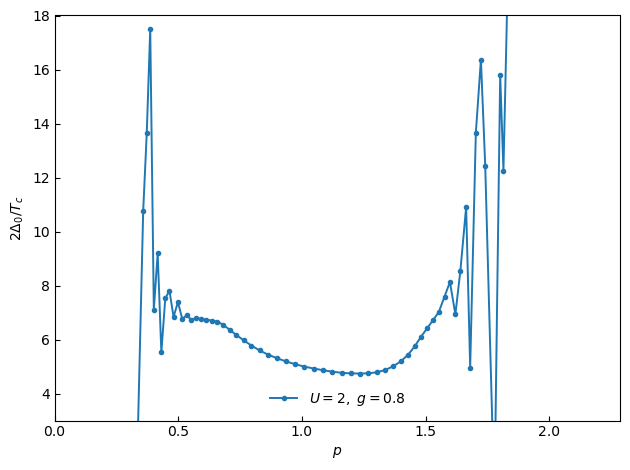

Loaded gap from: mean_field_gap.npy
Number of plotted points: 62
ratio range: 0 to 57.1771


In [2]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np


# -------------------------- paths --------------------------
data_dir = Path(".").resolve()
os.chdir(data_dir)

style_path = data_dir / "publication.mplstyle"
if style_path.exists():
    plt.style.use(style_path)


# -------------------------- user parameters --------------------------
U = 2
g = 0.8
Nk = 256

gap_filename = "mean_field_gap.npy"

# Use 2.0 for 2 Delta / Tc.
ratio_prefactor = 4.0

use_doping_mask = True
doping_min = 0.1
doping_max = 0.8

xlim = (0.0, 0.8/0.35)
ylim = (3.0, 18.0)


# -------------------------- load data --------------------------
gap_final = np.load(gap_filename)

Tc_final = np.load(f"Tc_U{U:g}_g{g:g}_N{Nk:g}_variational.npy")
x_final = np.load(f"x_U{U:g}_g{g:g}_N{Nk:g}_variational.npy")

gap_final = np.asarray(gap_final, dtype=float)
Tc_final = np.asarray(Tc_final, dtype=float)
x_final = np.asarray(x_final, dtype=float)


# -------------------------- align data --------------------------
if len(gap_final) != len(Tc_final):
    raise ValueError(
        f"Length mismatch: len(gap_final)={len(gap_final)}, "
        f"len(Tc_final)={len(Tc_final)}. "
        "Make sure test.npy and the Tc/x variational files use the same "
        "mu range and the same doping mask."
    )

if len(x_final) != len(Tc_final):
    raise ValueError(
        f"Length mismatch: len(x_final)={len(x_final)}, "
        f"len(Tc_final)={len(Tc_final)}."
    )


# -------------------------- mask and ratio --------------------------
valid = np.isfinite(gap_final) & np.isfinite(Tc_final) & np.isfinite(x_final)
valid &= Tc_final > 0.0

if use_doping_mask:
    valid &= x_final >= doping_min
    valid &= x_final < doping_max

x_plot = x_final[valid]
gap_plot = gap_final[valid]
Tc_plot = Tc_final[valid]

ratio_plot = ratio_prefactor * gap_plot / Tc_plot

sort_indices = np.argsort(x_plot)
x_plot = x_plot[sort_indices]
ratio_plot = ratio_plot[sort_indices]


# -------------------------- plot --------------------------
fig, ax = plt.subplots()

ax.plot(
    x_plot/0.35,
    ratio_plot,
    "o-",
    linewidth=1.4,
    markersize=3.0,
    color="C0",
    label=rf"$U={U:g},\ g={g:g}$",
)

ax.set_xlabel(r"$p$")
ax.set_ylabel(r"$2\Delta_0/T_c$")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax.legend(frameon=False)
ax.tick_params(direction="in")

fig.tight_layout()

# plt.savefig("gap_over_Tc.pdf", bbox_inches="tight")
# plt.close()
plt.show()


print(f"Loaded gap from: {gap_filename}")
print(f"Number of plotted points: {len(x_plot)}")
print(f"ratio range: {np.min(ratio_plot):.6g} to {np.max(ratio_plot):.6g}")